# Código atualizado


In [1]:
# ============================================
# 0) Imports
# ============================================
import warnings

import numpy as np
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier 

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
RNG_SEED = 42

OUTPUT_DIR = 'output'
DATASET_REDUCED = OUTPUT_DIR + '/dataset_reduced.csv'

CORRELATION_THRESHOLD = 0.9
CORRELATION_LIST = OUTPUT_DIR + '/lista_correlacao_reduced.csv'
CORRELATION_GRAPH = OUTPUT_DIR + '/correlation_heatmap_reduced.png'

CONSENSUS_RANKING = OUTPUT_DIR + '/ranking_importancia_reduced.csv'
CONSENSUS_TOP_K = 16

RESULT_REDUCED = OUTPUT_DIR + '/resultados_reduced'

np.random.seed(RNG_SEED)


In [3]:
# ============================================
# 1) Carregar datasets
# ============================================
df = pd.read_csv(DATASET_REDUCED)
print("Shape: ", df.shape)

Shape:  (81, 18)


In [4]:
# ============================================
# 2) Preparar X, y e grupos
# Removemos metadados e o target das features
# ============================================

cols_to_drop = ["status", "subject_id"]
feature_cols = [c for c in df.columns if c not in cols_to_drop]

X = df[feature_cols]
y = df["status"].astype(int)
groups = df["subject_id"]

print("Colunas a serem descartadas:", cols_to_drop)
print("Colunas de features:", feature_cols)
print(len(feature_cols), "features selecionadas.")
print("\nBalanceamento:")
print(pd.Series(y).value_counts().rename(index={0: "Controle(0)", 1: "Parkinson(1)"}))

Colunas a serem descartadas: ['status', 'subject_id']
Colunas de features: ['mfcc13_std', 'mfcc2_mean', 'mfcc11_std', 'shimmer_local', 'mfcc10_std', 'mfcc1_std', 'mfcc3_std', 'dmfcc6_std', 'mfcc9_std', 'dmfcc3_mean', 'dmfcc7_std', 'dmfcc13_mean', 'spec_centroid_mean_hz', 'dmfcc11_std', 'dmfcc13_std', 'spec_rolloff_std_hz']
16 features selecionadas.

Balanceamento:
status
Controle(0)     41
Parkinson(1)    40
Name: count, dtype: int64


In [5]:
# ============================================
# 5) Split Treino/Teste SEM leakage (por sujeito) 80/20
#    (apenas cria os índices; não treina nada aqui)
# ============================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RNG_SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# verificando a integridade
train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])
intersection = train_subjects.intersection(test_subjects)

print(f"Sujeitos no Treino: {len(train_subjects)} | Teste: {len(test_subjects)}")
print(f"Leakage check (deve ser 0): {len(intersection)} interseções encontradas.")
if len(intersection) != 0:
    raise ValueError("Houve leakage: mesmos sujeitos em treino e teste.")

Sujeitos no Treino: 64 | Teste: 17
Leakage check (deve ser 0): 0 interseções encontradas.


In [6]:
# ============================================
# 6) QuantileClipper
# ============================================
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        # Calcula os limites (quantis) para cada coluna
        self.lo_ = np.nanquantile(X, self.low, axis=0)
        self.hi_ = np.nanquantile(X, self.high, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        # Aplica o limitador: valores abaixo de lo_ viram lo_ 
        # e acima de hi_ viram hi_
        return np.clip(X, self.lo_, self.hi_)

Top 15 correlações mais altas:
dmfcc13_std  mfcc13_std     0.830882
mfcc3_std    mfcc1_std      0.807223
dmfcc11_std  dmfcc6_std     0.752134
dmfcc7_std   dmfcc6_std     0.738703
dmfcc11_std  mfcc11_std     0.722387
             mfcc9_std      0.721015
dmfcc13_std  dmfcc11_std    0.712988
mfcc11_std   mfcc13_std     0.699812
dmfcc11_std  dmfcc7_std     0.692630
dmfcc7_std   mfcc9_std      0.689020
mfcc9_std    mfcc11_std     0.685038
             dmfcc6_std     0.671161
mfcc10_std   mfcc13_std     0.658906
dmfcc13_std  dmfcc6_std     0.655298
mfcc9_std    mfcc10_std     0.649554
dtype: float64


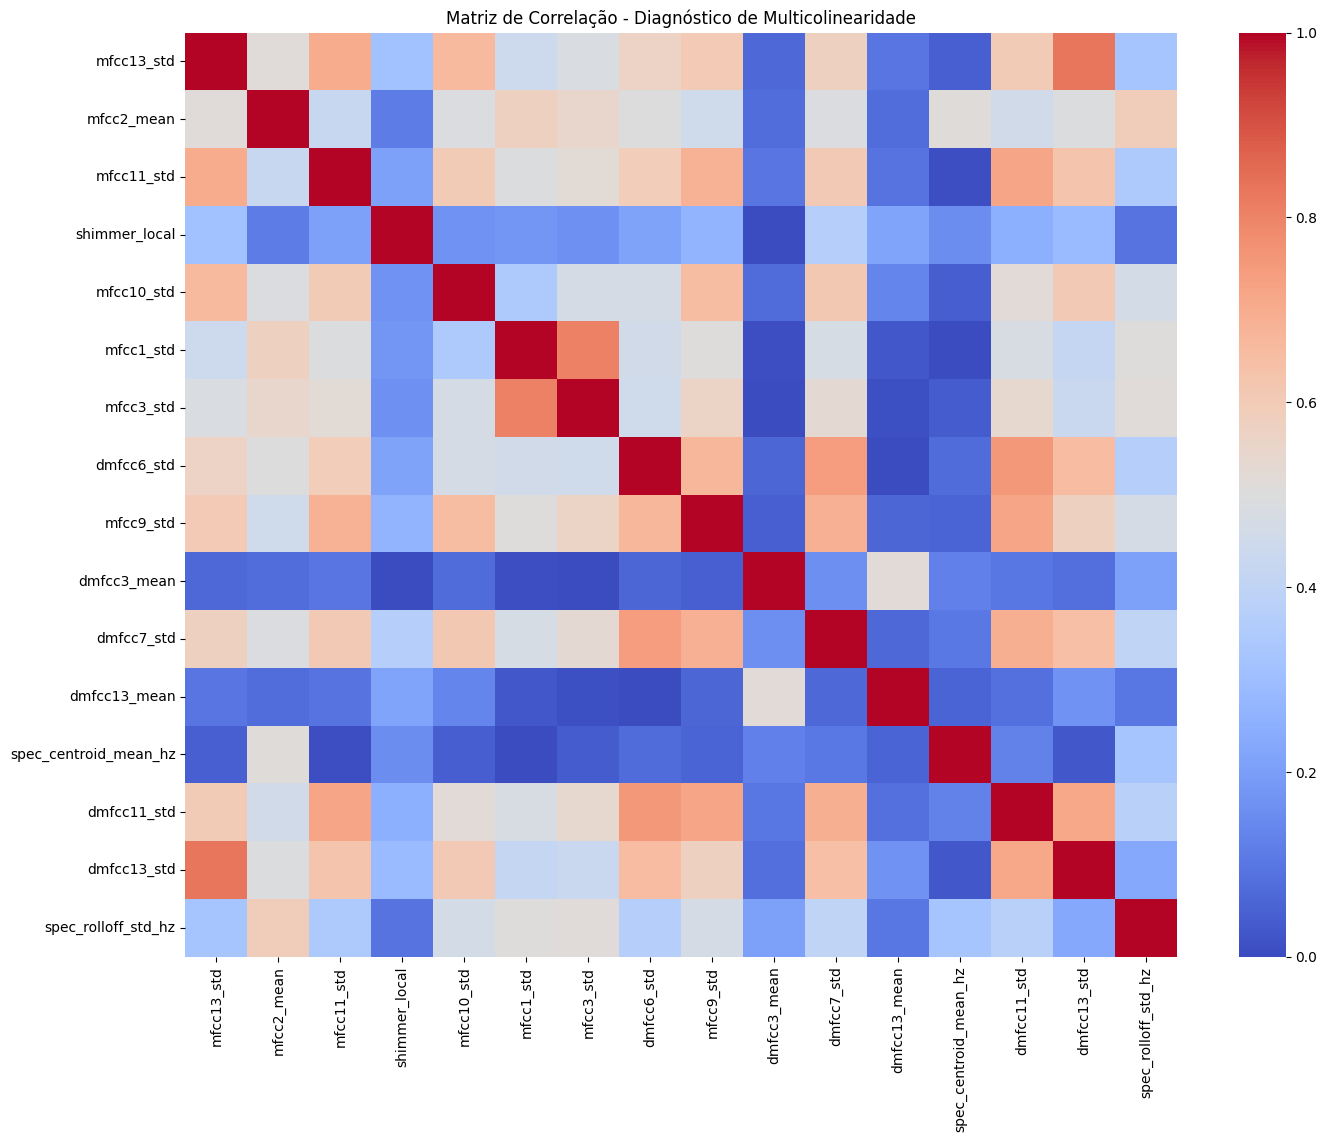


Número de colunas com correlação > 0.9: 0


In [7]:
# ============================================
# 7) analise de multicolinearidade
# ============================================

# Carregar o dataset imputado
df_analise = pd.read_csv(DATASET_REDUCED)

# Remover colunas não numéricas para o cálculo de correlação
cols_to_exclude = ['status', 'subject_id']
df_numeric = df_analise.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Calcular a matriz de correlação (Pearson)
corr_matrix = df_numeric.corr().abs()

# Selecionar o triângulo superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior a CORRELATION_THRESHOLD
highly_correlated = [column for column in upper.columns if any(upper[column] > CORRELATION_THRESHOLD)]

# Preparar dados para visualização (top correlações)
unstacked_corr = upper.unstack().dropna()
sorted_corr = unstacked_corr.sort_values(ascending=False)

# Convertendo a Series para DataFrame para um CSV mais limpo
df_corr_export = sorted_corr.reset_index()
df_corr_export.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Salvar correlações em CSV
df_corr_export.to_csv(CORRELATION_LIST, index=False)

# Mostrar as 15 maiores correlações
print("Top 15 correlações mais altas:")
print(sorted_corr.head(15))

# Plotar um Heatmap das correlações
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Matriz de Correlação - Diagnóstico de Multicolinearidade")
plt.savefig(CORRELATION_GRAPH)
plt.show()

# Contagem de colunas problemáticas
print(f"\nNúmero de colunas com correlação > {CORRELATION_THRESHOLD}: {len(highly_correlated)}")

In [8]:
# ============================================
# 8) Função: consenso de features
# ============================================
def get_consensus_features(rf_imp, xgb_imp, cat_imp, top_k=16):
    """Combine rankings of the 3 models to obtain consensus on the best features"""

   # Garante que os DataFrames de importância estejam ordenados para gerar o rank correto
    rf_ranked = rf_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)
    xgb_ranked = xgb_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)
    cat_ranked = cat_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)

    # Cria dicionários {nome_da_feature: posicao_no_rank}
    rf_rank_dict = {row['feature']: idx + 1 for idx, row in rf_ranked.iterrows()}
    xgb_rank_dict = {row['feature']: idx + 1 for idx, row in xgb_ranked.iterrows()}
    cat_rank_dict = {row['feature']: idx + 1 for idx, row in cat_ranked.iterrows()}
    
    all_features = set(rf_rank_dict.keys()) | set(xgb_rank_dict.keys()) | set(cat_rank_dict.keys())

    consensus_data = []
    for feature in all_features:
        # Busca a posição em cada modelo (se não existir, penaliza com o pior rank + 1)
        r_pos = rf_rank_dict.get(feature, len(rf_ranked) + 1)
        x_pos = xgb_rank_dict.get(feature, len(xgb_ranked) + 1)
        c_pos = cat_rank_dict.get(feature, len(cat_ranked) + 1)
        
        avg_rank = (r_pos + x_pos + c_pos) / 3
        consensus_data.append({
            'feature': feature,
            'rf_rank': r_pos,
            'xgb_rank': x_pos,
            'cat_rank': c_pos,
            'average_rank': avg_rank
        })
    
    # Ordena pelo rank médio (quanto menor, mais importante)
    df_consensus = pd.DataFrame(consensus_data).sort_values(by='average_rank').reset_index(drop=True)
    df_consensus.insert(0, 'final_rank', df_consensus.index + 1) # Insere a coluna de posição final

    return df_consensus

In [9]:
# Pré-processamento comum
preprocess = ImbPipeline(steps=[
    ("clip", QuantileClipper(0.01, 0.99)),
    ("scale", RobustScaler())
])

X_proc = preprocess.fit_transform(X)


In [10]:
# recarregando dataset
df_tsallis = pd.read_csv(DATASET_REDUCED)
cols_to_exclude = ['status','subject_id']
feature_cols = [c for c in df_tsallis.columns if c not in cols_to_exclude]
df = df_tsallis.drop(columns=cols_to_exclude)

In [11]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RNG_SEED,
    class_weight="balanced"
)

rf.fit(X_proc, y)

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)



# XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RNG_SEED
)
xgb.fit(X_proc, y)
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)


# CatBoost
cat = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    allow_writing_files=False,
    random_seed=RNG_SEED
)
cat.fit(X_proc, y)
cat_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": cat.get_feature_importance()
}).sort_values("importance", ascending=False)

In [12]:
# Obter o DataFrame completo de consenso
df_ranking_completo = get_consensus_features(
    rf_imp=rf_importance,
    xgb_imp=xgb_importance,
    cat_imp=cat_importance,
    top_k=len(feature_cols) # Pega todas as features para o CSV
)

# Salvar o ranking detalhado em CSV
df_ranking_completo.to_csv(CONSENSUS_RANKING, index=False)
print(f"\nArquivo {CONSENSUS_RANKING} salvo com sucesso.")


Arquivo output/ranking_importancia_reduced.csv salvo com sucesso.


In [13]:
# Seleciona TOP_K features principais para uso no modelo
top_features_list = df_ranking_completo['feature'].head(CONSENSUS_TOP_K).tolist()

# 3. Mostrar as TOP_K melhores no console
print(f"Top {CONSENSUS_TOP_K} features por consenso:")
print(df_ranking_completo[['final_rank', 'feature', 'average_rank']].head(CONSENSUS_TOP_K))

selected_features = top_features_list
missing = set(selected_features) - set(df.columns)
if missing:
    raise ValueError(f"Colunas selecionadas não encontradas no dataset: {missing}")


Top 16 features por consenso:
    final_rank                feature  average_rank
0            1             mfcc13_std      2.000000
1            2             mfcc11_std      2.666667
2            3            dmfcc3_mean      4.000000
3            4          shimmer_local      5.666667
4            5              mfcc9_std      6.000000
5            6              mfcc1_std      6.333333
6            7             mfcc10_std      6.666667
7            8    spec_rolloff_std_hz      8.333333
8            9              mfcc3_std      9.000000
9           10             mfcc2_mean      9.333333
10          11             dmfcc6_std     10.000000
11          12            dmfcc11_std     11.666667
12          13  spec_centroid_mean_hz     12.333333
13          14           dmfcc13_mean     13.000000
14          15             dmfcc7_std     13.666667
15          16            dmfcc13_std     15.333333


In [14]:
def make_pipeline(model):
    return ImbPipeline(steps=[
        # 1. Imputação: Garante que não haja nulos entrando nos transformadores
        ("imputer", SimpleImputer(strategy='median')),

        # 2. Clipping: Amortece os outliers extremos antes do escalonamento
        ("clip", QuantileClipper(0.01, 0.99)),
        
        # 3. RobustScaler: Escalonamento robusto baseado em quartis
        ("scale", RobustScaler()),

        # 4. SMOTE: Balanceamento sintético aplicado apenas durante o 'fit' (treino)
        ("smote", SMOTE(random_state=RNG_SEED, k_neighbors=3)),

        # 5. O Classificador (SVC, XGBoost, etc.)
        ("clf", model)
    ])
    

In [15]:
# =========================================================
# 13) Benchmark: roda GroupKFold CV e devolve tabela resumo
# =========================================================
def benchmark_models(X, y, groups, models_dict, n_splits=5, n_jobs=1):
    cv = GroupKFold(n_splits=n_splits)

    scoring = {
        "bal_acc": "balanced_accuracy",
        "roc_auc": "roc_auc",
        "f1": "f1",
    }

    rows = []
    for name, model in models_dict.items():
        pipe = make_pipeline(model)

        scores = cross_validate(
            pipe, X, y,
            groups=groups,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            error_score="raise"
        )

        rows.append({
            "model": name,
            "bal_acc_mean": float(np.mean(scores["test_bal_acc"])),
            "bal_acc_std":  float(np.std(scores["test_bal_acc"])),
            "roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
            "roc_auc_std":  float(np.std(scores["test_roc_auc"])),
            "f1_mean":      float(np.mean(scores["test_f1"])),
            "f1_std":       float(np.std(scores["test_f1"])),
        })

    return pd.DataFrame(rows).sort_values("bal_acc_mean", ascending=False).reset_index(drop=True)


In [16]:
# =========================================================
# 14) Carregar dataset para benchmarking
# =========================================================
df = pd.read_csv(DATASET_REDUCED)
feature_cols = [c for c in df.columns if c not in ["status", "subject_id"]]

X = df[feature_cols].values
y = df["status"].astype(int).values
groups = df["subject_id"].values

print("Dataset usado:", DATASET_REDUCED)
print("Shape:", df.shape)
print("Nº features:", len(feature_cols))
print("Nº sujeitos:", df["subject_id"].nunique())
print("Balanceamento:", pd.Series(y).value_counts().to_dict())

Dataset usado: output/dataset_reduced.csv
Shape: (81, 18)
Nº features: 16
Nº sujeitos: 81
Balanceamento: {0: 41, 1: 40}


In [17]:
# =========================================================
# 15) Modelos Classicos - Ajuste fino
# =========================================================


models = {
    #0.713889 
    "logreg_l2": LogisticRegression(
            C=0.5,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=RNG_SEED,
        ),
    # 0.640278
    "svc_rbf":  SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RNG_SEED,
        ),
    # 0.663889
    "linear_svc_cal": CalibratedClassifierCV(
            estimator=LinearSVC(
                C=0.1,
                class_weight="balanced",
                random_state=RNG_SEED,
                max_iter=10000,
                dual=False
            ),
            method="sigmoid",
            cv=3,
        ),
    # 0.726389
    "random_forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=3,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RNG_SEED,
            n_jobs=-1,
        ),
    # 0.640278
    "gradient_boosting": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.02,
            max_depth=2,
            subsample=0.6,          # Treina com apenas 60% das linhas por árvore (estocástico)
            random_state=RNG_SEED,
        ),
    # 0.727778 -> adaboost      0.702778     0.046356      0.848785     0.054560
    "adaboost": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=RNG_SEED),
            n_estimators=100,
            learning_rate=0.5,            
            random_state=RNG_SEED,
        ),
    # 0.541667
    "decision_tree": DecisionTreeClassifier(
            max_depth=2,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RNG_SEED,
        ),
    # -------------------------
    # KNN (não tem random_state)
    # -------------------------
    # 0.740278
    "knn": KNeighborsClassifier(
            n_neighbors=7,
            weights="uniform",
            metric="minkowski",
            p=2,
        ),
    
    # -------------------------
    # MLP (rede rasa)
    # -------------------------
    # 0.640278
    "mlp": MLPClassifier(
            hidden_layer_sizes=(4,),
            solver='lbfgs',
            alpha=1.0,
            max_iter=500,
            random_state=RNG_SEED,
            early_stopping=True,
            validation_fraction=0.1
        ),
    # -------------------------
    # XGBoost / CatBoost
    # -------------------------
    # 0.738889 -> xgboost      0.738889     0.047222      0.788021     0.028603
    "xgboost": XGBClassifier(
            n_estimators=150,
            max_depth=2,
            learning_rate=0.02,
            subsample=0.6,          # Cada árvore vê apenas 60% das 81 linhas
            colsample_bytree=0.6,   # Cada árvore vê apenas 60% das 16 colunas
            # 3. Regularização Pesada (Os "Freios")
            gamma=2,                # Exige uma redução mínima de perda para criar um novo corte (poda)
            reg_alpha=1.0,          # Regularização L1 (torna os pesos esparsos)
            reg_lambda=2.0,         # Regularização L2 (achata os pesos)
            min_child_weight=5,
            objective="binary:logistic",
            random_state=RNG_SEED,
            n_jobs=-1,
            verbosity=0,
        ),
    # 0.676389 ->   0.726389||0.116253  0.851042||0.067153
    "catboost": CatBoostClassifier(
        iterations=200, 
        depth=2, 
        learning_rate=0.02,
        l2_leaf_reg=10,          # Aumenta regularização L2
        bootstrap_type='Bernoulli',
        subsample=0.5,
        loss_function='Logloss', 
        verbose=0, 
        random_seed=RNG_SEED,
        allow_writing_files=False # Evita criar a pasta catboost_info
    ),

    # 0.663889
    "lightgbm": LGBMClassifier(
        n_estimators=100, 
        learning_rate=0.02, 
        num_leaves=3,
        min_child_samples=5,
        boosting_type='goss',
        random_state=RNG_SEED, 
        n_jobs=-1, 
        colsample_bytree=0.5,
        importance_type='gain',
        verbosity=-1,

    )

}


In [18]:
# =========================================================
# 16) Rodar benchmark (GroupKFold por sujeito)
# =========================================================
results = benchmark_models(X, y, groups, models, n_splits=5, n_jobs=1)

# Mostrar ranking
print("\n=== Ranking por Balanced Accuracy (GroupKFold, sem leakage) ===")
print(results)


=== Ranking por Balanced Accuracy (GroupKFold, sem leakage) ===
                model  bal_acc_mean  bal_acc_std  roc_auc_mean  roc_auc_std  \
0             xgboost      0.765278     0.046356      0.814757     0.048956   
1                 knn      0.740278     0.026932      0.802951     0.057844   
2             svc_rbf      0.738889     0.092087      0.797917     0.072424   
3            catboost      0.738889     0.107726      0.826042     0.048925   
4                 mlp      0.715278     0.084140      0.784375     0.076801   
5       random_forest      0.713889     0.102100      0.826042     0.066667   
6           logreg_l2      0.713889     0.075742      0.803819     0.073419   
7      linear_svc_cal      0.713889     0.075742      0.813542     0.076787   
8   gradient_boosting      0.713889     0.051107      0.827431     0.059855   
9            adaboost      0.704167     0.046398      0.841667     0.066422   
10           lightgbm      0.676389     0.101074      0.760764    

In [19]:
# -------------- salvando resultados ------------------
results.to_csv(RESULT_REDUCED, index=False)
print(f'Resultados salvos no arquivo {RESULT_REDUCED}')

Resultados salvos no arquivo output/resultados_reduced
